# Proyecto: Daisyworld 🌼🌎

Este notebook implementa una primera versión del modelo espacial de Daisyworld. El objetivo es evolucionar de un sistema de Ecuaciones Diferenciales Ordinarias (EDO) a un sistema de Ecuaciones en Derivadas Parciales (EDP), simulando un dominio cuadrado con condiciones de borde periódicas (bucles espacio-temporales para simular un planeta esférico).

Se calcularán y graficarán tanto la evolución temporal de los valores medios globales como la distribución espacial 2D en el estado final. Además de una animación donde se aprecie cómo las flores compiten por territorio.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Configuración para que los gráficos se vean bien en el notebook
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)

## 1. Definición de Parámetros y Dominio
A continuación, definimos las constantes físicas y biológicas del modelo, así como la discretización del espacio y el tiempo.

In [ ]:
# --- Parámetros del Dominio Espacial y Temporal ---
N = 1000           # Tamaño de la grilla (N x N)
L = 1000.0        # Tamaño físico del dominio
dx = L / N       # Paso espacial
dt = 0.01         # Paso temporal (debe ser "pequeño")
pasos = 2500     # Número de iteraciones

# --- Parámetros Físicos (Termodinámica) ---
K = 10.0         # Conductividad térmica
S = 3352.0       # CORREGIDO: Sol más luminoso para compensar la falta de atmósfera
sigma = 5.67e-8  # Constante de Stefan-Boltzmann real
C = 100.0        # Inercia térmica / Capacidad calorífica para estabilizar el modelo
A_w = 0.75       # Albedo de margaritas blancas (reflejan luz)
A_b = 0.25       # Albedo de margaritas negras (absorben luz)
A_s = 0.50       # Albedo del suelo desnudo

# --- Parámetros Biológicos ---
D_w = 2.0        # Coeficiente de difusión (dispersión) margaritas blancas
D_b = 2.0        # Coeficiente de difusión (dispersión) margaritas negras
gamma = 0.3      # Tasa de mortalidad constante
T_opt = 22.5     # Temperatura óptima de crecimiento

## 2. Operador Laplaciano Periódico
Para la difusión, utilizamos diferencias finitas centradas. La condición de borde periódica (topología toroidal) se implementa de manera eficiente utilizando la función `np.roll` de NumPy, la cual "envuelve" los bordes de la matriz.

El operador aproxima: $$\nabla^2 U \approx \frac{\partial^2 U}{\partial x^2} + \frac{\partial^2 U}{\partial y^2}$$

In [ ]:
def laplacian_2d(U, dx):
    """
    Calcula el Laplaciano 2D usando diferencias finitas con condiciones
    de borde periódicas.
    """
    lap_x = (np.roll(U, -1, axis=0) - 2.0 * U + np.roll(U, 1, axis=0)) / (dx**2)
    lap_y = (np.roll(U, -1, axis=1) - 2.0 * U + np.roll(U, 1, axis=1)) / (dx**2)
    return lap_x + lap_y

def tasa_crecimiento(T):
    """
    Función de crecimiento biológico tipo parábola invertida.
    Solo es positiva entre 5 y 40 grados.
    """
    beta = 1.0 - 0.003265 * (T - T_opt)**2
    # Evitar tasas negativas usando np.maximum
    return np.maximum(0.0, beta)

## 3. Condiciones Iniciales
Inicializamos el planeta con una temperatura uniforme y densidades bajas de margaritas. Para fomentar la dinámica espacial, introducimos una pequeña perturbación aleatoria en las poblaciones iniciales.

In [ ]:
# Inicialización de matrices (N x N)
T = np.ones((N, N)) * 20.0  # Temperatura inicial uniforme

# Empezamos con el planeta vacío (0 margaritas)
alpha_w = np.zeros((N, N))
alpha_b = np.zeros((N, N))

# Plantamos un "parche" de margaritas blancas en una esquina
alpha_w[10:20, 10:20] = 0.5

# Plantamos un "parche" de margaritas negras en la esquina opuesta
alpha_b[30:40, 30:40] = 0.5

# Listas para almacenar los valores medios a lo largo del tiempo
tiempos = []
T_mean = []
alpha_w_mean = []
alpha_b_mean = []

## 4. Bucle Principal de Simulación
Resolvemos el sistema acoplado de ecuaciones de reacción-difusión utilizando el método de Euler hacia adelante. En cada iteración, se calcula el albedo local, se aplican los operadores de difusión y se actualiza el estado del sistema. También registramos los promedios globales.

In [ ]:
from tqdm.auto import tqdm

# Listas para guardar las matrices 2D (fotogramas)
historial_T = []
historial_w = []
historial_b = []

pasos_por_fotograma = 10 # Guardar un frame cada 10 iteraciones


# Inicio simulación ---
for step in tqdm(range(pasos), desc="Simulando Daisyworld"):
    # 1. Albedo local
    A_p = alpha_w * A_w + alpha_b * A_b + (1.0 - alpha_w - alpha_b) * A_s

    # 2. Espacio libre para crecer
    espacio_libre = 1.0 - alpha_w - alpha_b
    espacio_libre = np.maximum(0.0, espacio_libre) # Físicamente no puede ser negativo

    # 3. Tasas de crecimiento locales
    beta_loc = tasa_crecimiento(T)

    # 4. Cálculo de Laplacianos (Difusión)
    lap_T = laplacian_2d(T, dx)
    lap_w = laplacian_2d(alpha_w, dx)
    lap_b = laplacian_2d(alpha_b, dx)

    # 5. Ecuaciones de evolución (Reacción + Difusión)
    # Transformar a Kelvin para la ley de Stefan-Boltzmann
    T_kelvin = T + 273.15

    # Balance de energía real dividido por la inercia térmica (C)
    dT_dt = K * lap_T + ((S / 4.0) * (1.0 - A_p) - sigma * (T_kelvin**4)) / C

    dw_dt = alpha_w * (beta_loc * espacio_libre - gamma) + D_w * lap_w
    db_dt = alpha_b * (beta_loc * espacio_libre - gamma) + D_b * lap_b

    # 6. Actualización (Euler explícito)
    T = T + dt * dT_dt
    alpha_w = alpha_w + dt * dw_dt
    alpha_b = alpha_b + dt * db_dt

    # Asegurar que las fracciones poblacionales no sean negativas por errores numéricos
    alpha_w = np.maximum(0.0, alpha_w)
    alpha_b = np.maximum(0.0, alpha_b)

    # 7. Guardar valores medios y fotogramas
    tiempos.append(step * dt)
    T_mean.append(np.mean(T))
    alpha_w_mean.append(np.mean(alpha_w))
    alpha_b_mean.append(np.mean(alpha_b))
    if step % pasos_por_fotograma == 0:
        historial_T.append(T.copy())
        historial_w.append(alpha_w.copy())
        historial_b.append(alpha_b.copy())

print(f"\nSimulación lista. Se guardaron {len(historial_T)} fotogramas.")

Simulando Daisyworld:   0%|          | 0/10000 [00:00<?, ?it/s]

/tmp/ipykernel_9281/3935553969.py:15: RuntimeWarning: overflow encountered in square
  beta = 1.0 - 0.003265 * (T - T_opt)**2
/tmp/ipykernel_9281/1546862095.py:33: RuntimeWarning: overflow encountered in power
  dT_dt = K * lap_T + ((S / 4.0) * (1.0 - A_p) - sigma * (T_kelvin**4)) / C
/tmp/ipykernel_9281/3935553969.py:6: RuntimeWarning: invalid value encountered in subtract
  lap_x = (np.roll(U, -1, axis=0) - 2.0 * U + np.roll(U, 1, axis=0)) / (dx**2)
/tmp/ipykernel_9281/3935553969.py:6: RuntimeWarning: invalid value encountered in add
  lap_x = (np.roll(U, -1, axis=0) - 2.0 * U + np.roll(U, 1, axis=0)) / (dx**2)
/tmp/ipykernel_9281/3935553969.py:7: RuntimeWarning: invalid value encountered in subtract
  lap_y = (np.roll(U, -1, axis=1) - 2.0 * U + np.roll(U, 1, axis=1)) / (dx**2)
/tmp/ipykernel_9281/3935553969.py:7: RuntimeWarning: invalid value encountered in add
  lap_y = (np.roll(U, -1, axis=1) - 2.0 * U + np.roll(U, 1, axis=1)) / (dx**2)
/tmp/ipykernel_9281/1546862095.py:33: Runtim


Simulación lista. Se guardaron 100 fotogramas.


## 5. Resultados y Visualización (Valores medios y distribución espacial final)
Generamos los gráficos para visualizar:
1. **Gráfico 1D:** Evolución temporal de los valores medios globales (Temperatura y Poblaciones).
2. **Gráfico 2D:** Mapas de calor (Heatmaps) mostrando la distribución espacial final.

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
# Define your list of colors (names, HEX, or RGB)
colors = ["#f7f5bc", "#ece75f", "#e6b400"]

# Create the continuous colormap
flores_blancas = LinearSegmentedColormap.from_list("marg_blancas", colors)

# Define your list of colors (names, HEX, or RGB)
colors = ["#dcd7d0", "#cccccc", "#000000"]

# Create the continuous colormap
flores_negras = LinearSegmentedColormap.from_list("marg_negras", colors)

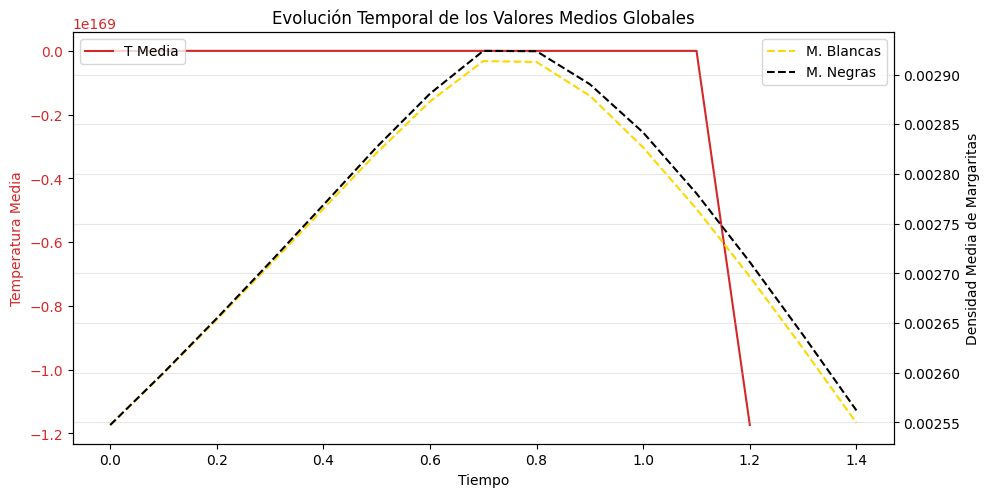

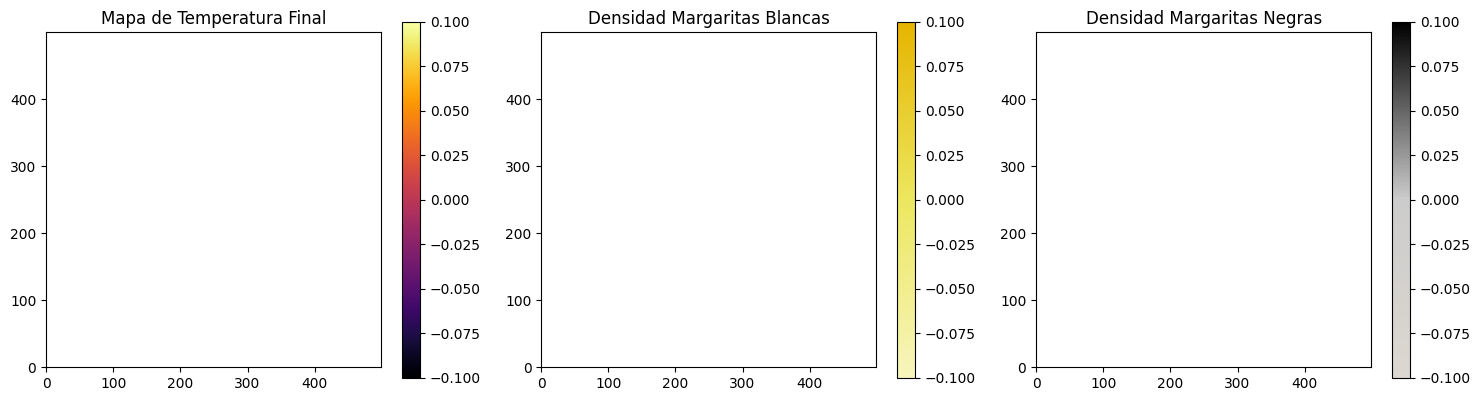

In [ ]:
# --- Gráfico de Evolución Temporal (Valores Medios) ---
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:red'
ax1.set_xlabel('Tiempo')
ax1.set_ylabel('Temperatura Media', color=color)
ax1.plot(tiempos, T_mean, color=color, label='T Media')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color_w = 'gold'
color_b = 'black'
ax2.set_ylabel('Densidad Media de Margaritas')
ax2.plot(tiempos, alpha_w_mean, color=color_w, label='M. Blancas', linestyle='--')
ax2.plot(tiempos, alpha_b_mean, color=color_b, label='M. Negras', linestyle='--')
ax2.tick_params(axis='y')

fig.tight_layout()
plt.title('Evolución Temporal de los Valores Medios Globales')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

# --- Gráficos Espaciales 2D (Estado Final) ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Mapa de Temperatura
im1 = axes[0].imshow(T, cmap='inferno', origin='lower')
axes[0].set_title('Mapa de Temperatura Final')
fig.colorbar(im1, ax=axes[0])

# Mapa Margaritas Blancas
im2 = axes[1].imshow(alpha_w, cmap=flores_blancas, origin='lower', vmin=0)
axes[1].set_title('Densidad Margaritas Blancas')
fig.colorbar(im2, ax=axes[1])

# Mapa Margaritas Negras
im3 = axes[2].imshow(alpha_b, cmap=flores_negras, origin='lower', vmin=0)
axes[2].set_title('Densidad Margaritas Negras')
fig.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()

## 6. Animación (Espacio-Temporal)
Generamos un video (animación) para apreciar la evolución de la población de margaritas.

In [ ]:
import matplotlib.animation as animation
from IPython.display import HTML

# Configurar la figura para la animación
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Inicializar las imágenes vacías con el primer fotograma
# Fijamos vmin y vmax para evitar que los colores parpadeen
im_T = axes[0].imshow(historial_T[0], cmap='inferno', origin='lower', vmin=np.min(historial_T), vmax=np.max(historial_T))
im_w = axes[1].imshow(historial_w[0], cmap=flores_blancas, origin='lower', vmin=0, vmax=np.max(historial_w))
im_b = axes[2].imshow(historial_b[0], cmap=flores_negras, origin='lower', vmin=0, vmax=np.max(historial_b))

# Títulos
axes[0].set_title('Temperatura')
axes[1].set_title('Margaritas Blancas')
axes[2].set_title('Margaritas Negras')

# Añadir barras de color
fig.colorbar(im_T, ax=axes[0], fraction=0.046, pad=0.04)
fig.colorbar(im_w, ax=axes[1], fraction=0.046, pad=0.04)
fig.colorbar(im_b, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()

# Función que actualiza la figura en cada frame
def update(frame):
    im_T.set_array(historial_T[frame])
    im_w.set_array(historial_w[frame])
    im_b.set_array(historial_b[frame])
    fig.suptitle(f"Tiempo: {frame * dt * pasos_por_fotograma:.1f}", fontsize=16)
    return [im_T, im_w, im_b]

# Crear la animación
ani = animation.FuncAnimation(fig, update, frames=len(historial_T), interval=50, blit=False)

# Cerrar la figura estática para que no se muestre doble en el notebook
plt.close()

# Mostrar el video HTML5 interactivo directamente en el Notebook
HTML(ani.to_jshtml())